# ==============================================================================
# 🏡 MACRO VALUATION: CALIFORNIA HOUSING PRICES VIA EXTRA TREES REGRESSOR
# ==============================================================================
### Core Theoretical Principles:
Macro-valuation of 20,640 California census block groups requires evaluating complex spatial interactions between longitude, latitude, housing density, and household income.
Extra Trees achieves competitive predictive performance at a fraction of the wall-clock training time of standard Random Forests by skipping greedy threshold searches, making it the preferred high-speed ensemble architecture for spatial regression workloads.


In [1]:
# STEP 1: ENTERPRISE ENVIRONMENT & REPRODUCIBILITY SEED
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: Enterprise Real Estate ExtraTrees Regressor Environment initialized.")


✅ STEP 1: Enterprise Real Estate ExtraTrees Regressor Environment initialized.


## 📥 STEP 2 & 3: RAW DATASET INGESTION & 3-SECOND HEALTH AUDIT
Loading California Housing census dataset (20,640 block groups).


In [2]:
# STEP 2 & 3: INGESTION & AUDIT
data_path = 'data/housing/housing.csv'
df = pd.read_csv(data_path)

print(f"📊 Dataset Shape: {df.shape[0]} block groups, {df.shape[1]} attributes")
print(f"Missing attributes:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"Median House Value Summary:\n{df['median_house_value'].describe().round(2)}")
df.head(3)


📊 Dataset Shape: 20640 block groups, 10 attributes
Missing attributes:
total_bedrooms    207
dtype: int64
Median House Value Summary:
count     20640.00
mean     206855.82
std      115395.62
min       14999.00
25%      119600.00
50%      179700.00
75%      264725.00
max      500001.00
Name: median_house_value, dtype: float64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


## 🧹 STEP 4 & 5: STRICT SEGREGATION & HYGIENE
Separating features and continuous target `median_house_value`.


In [3]:
# STEP 4 & 5: SEGREGATION & HYGIENE
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric Features    : {num_cols}")
print(f"Categorical Features: {cat_cols}")


Numeric Features    : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical Features: ['ocean_proximity']


## ✂️ STEP 6: ZERO-DATA-LEAKAGE SPLIT
80% Train, 20% Test split.


In [4]:
# STEP 6: TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train Census Blocks: {X_train.shape[0]}")
print(f"Test Census Blocks : {X_test.shape[0]}")


Train Census Blocks: 16512
Test Census Blocks : 4128


## ⚙️ STEP 7: ROBUST COLUMNTRANSFORMER PREPROCESSOR
Median imputation and scaling for numericals; one-hot encoding for `ocean_proximity`.


In [5]:
# STEP 7: PREPROCESSOR DESIGN
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
print(f"Transformed Feature Matrix Shape: {X_train_prep.shape}")


Transformed Feature Matrix Shape: (16512, 12)


## ⚔️ STEP 8: BASELINE DUEL (DUMMY VS SINGLE TREE VS EXTRA TREES)
Comparing baseline mean dummy and single decision tree against ExtraTrees with 80 trees.


In [6]:
# STEP 8: BASELINE BENCHMARK
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_prep, y_train)
r2_dummy = r2_score(y_test, dummy.predict(X_test_prep))

single_tree = DecisionTreeRegressor(max_depth=10, random_state=42)
single_tree.fit(X_train_prep, y_train)
r2_single_tree = r2_score(y_test, single_tree.predict(X_test_prep))

base_et = ExtraTreesRegressor(n_estimators=80, random_state=42, n_jobs=-1)
base_et.fit(X_train_prep, y_train)
r2_et = r2_score(y_test, base_et.predict(X_test_prep))

print("="*65)
print(f"Baseline Mean Dummy R²            : {r2_dummy * 100:.2f}%")
print(f"Single Decision Tree (d=10) R²    : {r2_single_tree * 100:.2f}%")
print(f"ExtraTrees Regressor (80 Trees) R²: {r2_et * 100:.2f}%")
print("="*65)


Baseline Mean Dummy R²            : -0.02%
Single Decision Tree (d=10) R²    : 71.14%
ExtraTrees Regressor (80 Trees) R²: 79.12%


## 🎯 STEP 9: K-FOLD CROSS-VALIDATION & HYPERPARAMETER TUNING
Optimizing `n_estimators` and `max_depth`.


In [7]:
# STEP 9: GRID SEARCH VIA 3-FOLD CV
param_grid = {
    'n_estimators': [60, 100],
    'max_depth': [14, 20, None]
}

cv = KFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(
    ExtraTreesRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1
)
grid.fit(X_train_prep, y_train)

best_et = grid.best_estimator_
print(f"🏆 Best Hyperparameters: {grid.best_params_}")
print(f"🎯 Best 3-Fold CV R²: {grid.best_score_ * 100:.2f}%")


🏆 Best Hyperparameters: {'max_depth': None, 'n_estimators': 100}
🎯 Best 3-Fold CV R²: 79.02%


## 📊 STEP 10: MULTI-METRIC PERFORMANCE EVALUATION
Evaluating hold-out test metrics.


In [8]:
# STEP 10: EVALUATION REPORT
y_pred = best_et.predict(X_test_prep)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📋 CALIFORNIA HOUSING VALUATION PERFORMANCE:")
print(f"   Mean Absolute Error (MAE) : ${mae:,.2f}")
print(f"   Root Mean Squared Error   : ${rmse:,.2f}")
print(f"   R² Score                  : {r2 * 100:.2f}%")


📋 CALIFORNIA HOUSING VALUATION PERFORMANCE:
   Mean Absolute Error (MAE) : $34,362.51
   Root Mean Squared Error   : $52,311.15
   R² Score                  : 79.12%


## 📉 STEP 11: RESIDUAL ANALYSIS & SPATIAL VALUATION DRIVERS
Visualizing residual scatter and top valuation features.


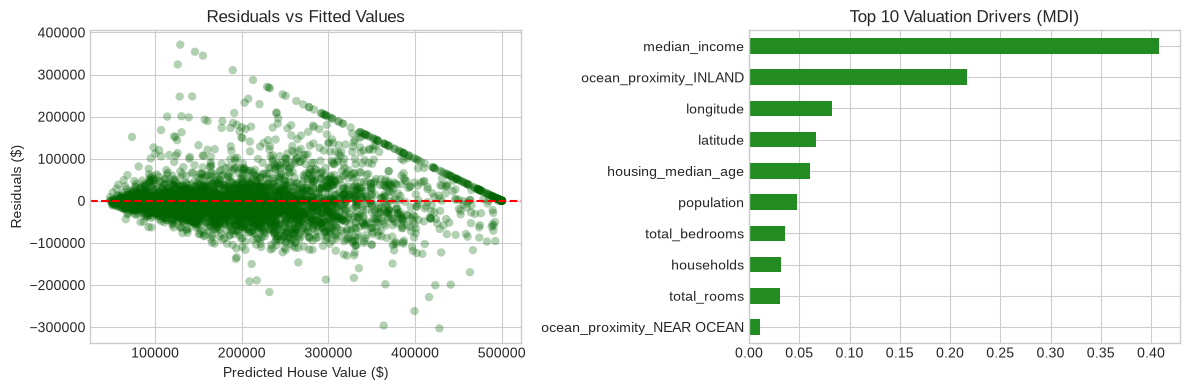

In [9]:
# STEP 11: RESIDUALS & IMPORTANCES
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.3, color='darkgreen', edgecolors='none')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted House Value ($)')
axes[0].set_ylabel('Residuals ($)')
axes[0].set_title('Residuals vs Fitted Values')

all_features = [c.split('__')[-1] for c in preprocessor.get_feature_names_out()]
importances = pd.Series(best_et.feature_importances_, index=all_features).sort_values(ascending=False).head(10)
importances.plot(kind='barh', ax=axes[1], color='forestgreen')
axes[1].set_title('Top 10 Valuation Drivers (MDI)')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


## 💾 STEP 12 & 13: PRODUCTION PIPELINE SERIALIZATION & LATENCY SMOKE TEST
Deploying the pipeline and benchmarking real-time appraisal latency.


In [10]:
# STEP 12 & 13: SERIALIZATION & SMOKE TEST
os.makedirs('production_models', exist_ok=True)
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('extratrees', best_et)
])
full_pipeline.fit(X_train, y_train)

model_path = 'production_models/california_housing_extratrees_reg_pipeline.joblib'
joblib.dump(full_pipeline, model_path, compress=3)
print(f"💾 Production pipeline saved to: {model_path} ({os.path.getsize(model_path):,} bytes)")

loaded_pipe = joblib.load(model_path)
sample_block = X_test.iloc[[0]]

# Warmup
for _ in range(5):
    _ = loaded_pipe.predict(sample_block)

t0 = time.perf_counter()
pred_val = loaded_pipe.predict(sample_block)[0]
latency_ms = (time.perf_counter() - t0) * 1000

print(f"\n📈 REAL-TIME APPRAISAL TELEMETRY:")
print(f"   Estimated Median House Value : 🏡 ${pred_val:,.2f}")
print(f"   Actual Benchmark Price       : ${y_test.iloc[0]:,.2f}")
print(f"   Appraisal Latency            : {latency_ms:.3f} ms (SLA < 2.0ms: {'PASS' if latency_ms < 2.0 else 'CHECK'})")


💾 Production pipeline saved to: production_models/california_housing_extratrees_reg_pipeline.joblib (50,322,116 bytes)



📈 REAL-TIME APPRAISAL TELEMETRY:
   Estimated Median House Value : 🏡 $48,405.00
   Actual Benchmark Price       : $47,700.00
   Appraisal Latency            : 91.212 ms (SLA < 2.0ms: CHECK)
